<a href="https://colab.research.google.com/github/yousseff2255/solship_hackathon/blob/main/forecaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#External data & Configuration

In [295]:
!pip install xgboost cvxpy holidays openpyxl -q
!pip install openmeteo-requests requests-cache retry-requests -q
!pip install lightgbm catboost -q

In [296]:
import holidays
import pandas as pd

def generate_italian_holidays():
    print("Generating Italian public holidays for 2024 and 2025...")

    # Initialize the Italy holiday calendar for the specific years
    it_holidays = holidays.Italy(years=[2024, 2025])

    # Convert the dictionary-like object into a list of tuples, then to a DataFrame
    holiday_data = list(it_holidays.items())
    df_holidays = pd.DataFrame(holiday_data, columns=['date', 'holiday_name'])

    # Convert the 'date' column to proper pandas datetime format
    df_holidays['date'] = pd.to_datetime(df_holidays['date'])

    # Add the binary feature flag for XGBoost
    df_holidays['is_holiday'] = 1

    # Sort chronologically just to be clean
    df_holidays = df_holidays.sort_values('date').reset_index(drop=True)

    print(f"Success! Found {len(df_holidays)} holidays.")
    return df_holidays

# Run the function
holiday_df = generate_italian_holidays()
holiday_df.head(10)


Generating Italian public holidays for 2024 and 2025...
Success! Found 26 holidays.


,date,holiday_name,is_holiday
0,2024-01-01,New Year's Day,1
1,2024-01-06,Epiphany,1
2,2024-03-31,Easter Sunday,1
3,2024-04-01,Easter Monday,1
4,2024-04-25,Liberation Day,1
5,2024-05-01,Labor Day,1
6,2024-06-02,Republic Day,1
7,2024-08-15,Assumption Of Mary Day,1
8,2024-11-01,All Saints' Day,1
9,2024-11-03,National Unity Day,1


In [297]:
import requests
import pandas as pd

def fetch_sondrio_weather():
    print("Fetching hourly weather data for Sondrio and interpolating to 15-min...")

    lat = 46.1709
    lon = 9.8715

    url = "https://archive-api.open-meteo.com/v1/archive"

    # Request HOURLY data
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2024-01-01",
        "end_date": "2025-12-31",
        "hourly": ["temperature_2m", "shortwave_radiation"],
        "timezone": "Europe/Rome"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()

    # Build the hourly DataFrame
    df = pd.DataFrame({
        "timestamp": pd.to_datetime(data["hourly"]["time"]),
        "temperature_2m": data["hourly"]["temperature_2m"],
        "solar_irradiance": data["hourly"]["shortwave_radiation"]
    })


    # 1. Set the timestamp as the index so pandas can manipulate the time
    df.set_index("timestamp", inplace=True)

    # 2. Resample to 15 minutes and linearly interpolate the gaps
    df_15min = df.resample("15min").interpolate(method="linear")

    # 3. Reset the index so timestamp goes back to being a normal column
    df_15min.reset_index(inplace=True)

    # Trim to strictly 2024-2025
    df_15min = df_15min[(df_15min['timestamp'].dt.year == 2024) | (df_15min['timestamp'].dt.year == 2025)]

    print(f"Success! Interpolated down to {len(df_15min)} 15-minute rows.")
    return df_15min



In [298]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

TEAL = '#00d4aa'
RED  = '#ff6b6b'
GOLD = '#ffd93d'
BLUE = '#4a9eff'
GREY = '#8b8fa8'
BG   = '#0f1117'
PANEL= '#1a1d27'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor': PANEL,
    'axes.edgecolor':  '#2e3147', 'axes.labelcolor': '#e8eaf0',
    'axes.titlecolor': '#e8eaf0', 'xtick.color': GREY,
    'ytick.color': GREY,          'grid.color':  '#2e3147',
    'text.color':  '#e8eaf0',     'axes.spines.top': False,
    'axes.spines.right': False,
})

#Data Loading

In [299]:
from google.colab import files
import pandas as pd

DATA_PATH = "Data/raw/ENERGY_Hackathon_DataSet(Sheet1).csv"

# Read the entire CSV file, assuming semicolon delimiter and comma decimal
df_full = pd.read_csv(DATA_PATH, sep=';', decimal=',')

# Standardize column names
def clean_cols(df):
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ','_').str.replace('(','').str.replace(')',''))
    return df

df_full = clean_cols(df_full)

df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])
df_full = df_full.drop_duplicates(subset='timestamp', keep='first').reset_index(drop=True)

# Filter for 2024 and 2025 data
df_2024 = df_full[df_full['timestamp'].dt.year == 2024].sort_values('timestamp').reset_index(drop=True)
df_2025 = df_full[df_full['timestamp'].dt.year == 2025].sort_values('timestamp').reset_index(drop=True)

print("Columns:", df_2024.columns.tolist())
print(f"2024: {len(df_2024):,} rows")
print(f"2025: {len(df_2025):,} rows")
df_2024.head()

Columns: ['battery_p', 'grid_p', 'load_p', 'pv_p', 'timestamp', 'selling_price_eur_kwh']
2024: 35,132 rows
2025: 34,941 rows


,battery_p,grid_p,load_p,pv_p,timestamp,selling_price_eur_kwh
0,0.0,3.04,3.05,0.0,2024-01-01 00:00:00,0.10709
1,0.0,0.34,0.34,0.0,2024-01-01 00:15:00,0.10709
2,0.0,0.37,0.37,0.0,2024-01-01 00:30:00,0.10709
3,0.0,0.37,0.37,0.0,2024-01-01 00:45:00,0.10709
4,0.0,2.40,2.40,0.0,2024-01-01 01:00:00,0.10400


In [300]:
# Merge holiday flag
df_2024['date'] = df_2024['timestamp'].dt.normalize() # Create 'date' column from 'timestamp'
df_2024 = df_2024.merge(holiday_df[['date', 'is_holiday']], on='date', how='left')
df_2024['is_holiday'].fillna(0, inplace=True)

# Merge weather data (temperature and solar irradiance)
# Ensure both dataframes have the same timestamp frequency (15-min)
weather_15min = fetch_sondrio_weather()   # already defined
df_2024 = df_2024.merge(weather_15min, on='timestamp', how='left')

Fetching hourly weather data for Sondrio and interpolating to 15-min...
Success! Interpolated down to 70173 15-minute rows.


In [301]:
def fix_time_gaps(df, year):
    df = df.copy()

    # Create the perfect timeline for that year
    start_time = f"{year}-01-01 00:00:00"
    end_time = f"{year}-12-31 23:45:00"
    perfect_index = pd.date_range(start=start_time, end=end_time, freq='15min')

    # Set timestamp as index, reindex to the perfect timeline, then reset index
    df = df.set_index('timestamp').reindex(perfect_index).reset_index()
    df = df.rename(columns={'index': 'timestamp'})

    # Fill the missing values
    # For 'load_p' and prices, linear interpolation is usually safest for small gaps
    df['load_p'] = df['load_p'].interpolate(method='linear')
    df['selling_price_eur_kwh'] = df['selling_price_eur_kwh'].ffill() # Prices often stay flat

    # For other power columns if they exist
    for col in ['pv_p', 'grid_p', 'battery_p']:
        if col in df.columns:
            df[col] = df[col].interpolate(method='linear')

    return df

# Apply the fix
df_2025 = fix_time_gaps(df_2025, 2025)

print(f"New 2025 count: {len(df_2025):,} (Expected: 35,040)")

New 2025 count: 35,040 (Expected: 35,040)


#EDA

In [302]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def explore_dataset(df, year_label='2024'):
    """
    Run full EDA on the dataset.
    Each plot answers one specific question.
    """
    # Assuming these are defined elsewhere in your notebook, if not, here are defaults:
    TEAL, GOLD, RED, BG, PANEL, BLUE, GREY = '#1f77b4', '#ff7f0e', '#d62728', 'white', '#f0f0f0', '#0000ff', '#808080'

    df = df.copy()
    df['hour']  = df['timestamp'].dt.hour
    df['dow']   = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['date']  = df['timestamp'].dt.date
    DAY_NAMES   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    MON_NAMES   = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']

    print(f"\n{'='*60}")
    print(f"  EDA — {year_label} Dataset")
    print(f"{'='*60}")
    print(f"  Rows     : {len(df):,}")
    print(f"  Range    : {df['timestamp'].min()} → {df['timestamp'].max()}")
    print(f"\n  Load  — min: {df['load_p'].min():.2f}  "
          f"max: {df['load_p'].max():.2f}  "
          f"mean: {df['load_p'].mean():.2f} kW")
    if 'pv_p' in df.columns:
        print(f"  PV    — max: {df['pv_p'].max():.2f}  "
              f"mean (daytime): {df[df['pv_p']>0]['pv_p'].mean():.2f} kW")
    print()

    # ────────────────────────────────────────────────────────────
    # PLOT 1 — Full year load signal
    # ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(18, 4))
    ax.plot(df['timestamp'], df['load_p'], color=TEAL, lw=0.3, alpha=0.8)
    ax.set_title(f'PLOT 1 — Full Year Load Signal\n'
                 f'❓ Is data complete? Any gaps or impossible spikes? '
                 f'Summer vs winter trend?',
                 fontsize=10)
    ax.set_ylabel('Load (kW)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'plot1_full_year_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 2 — One sample week (load + PV)
    # ────────────────────────────────────────────────────────────
    week_num = 10   # pick a spring week — change if needed
    sample   = df[df['timestamp'].dt.isocalendar().week == week_num]

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(sample['timestamp'], sample['load_p'],
            color=TEAL, lw=1.5, label='Load')
    if 'pv_p' in df.columns:
        ax.fill_between(sample['timestamp'], sample['pv_p'],
                        color=GOLD, alpha=0.5, label='PV generation')
    ax.set_title(f'PLOT 2 — Sample Week (Week {week_num})\n'
                 f'❓ Daily load pattern visible? '
                 f'Does PV reduce net grid consumption midday?',
                 fontsize=10)
    ax.set_ylabel('Power (kW)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
    plt.tight_layout()
    plt.savefig(f'plot2_sample_week_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 3 — Average load by hour (weekday vs weekend)
    # ────────────────────────────────────────────────────────────
    wd = df[df['dow'] < 5].groupby('hour')['load_p'].mean()
    we = df[df['dow'] >= 5].groupby('hour')['load_p'].mean()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(wd.index, wd.values, color=TEAL, lw=2,
            marker='o', ms=4, label='Weekday')
    ax.plot(we.index, we.values, color=RED,  lw=2,
            marker='o', ms=4, label='Weekend')
    ax.fill_between(wd.index, wd.values, we.values,
                    alpha=0.1, color=GOLD)

    # Annotate min and max
    ax.annotate(f'Min\n{wd.idxmin()}:00',
                xy=(wd.idxmin(), wd.min()),
                xytext=(wd.idxmin()+1, wd.min()-0.3),
                color=TEAL, fontsize=8,
                arrowprops=dict(arrowstyle='->', color=TEAL))
    ax.annotate(f'Max\n{wd.idxmax()}:00',
                xy=(wd.idxmax(), wd.max()),
                xytext=(wd.idxmax()+1, wd.max()+0.2),
                color=RED, fontsize=8,
                arrowprops=dict(arrowstyle='->', color=RED))

    ax.set_title('PLOT 3 — Average Hourly Load Profile\n'
                 '❓ When is load lowest? (= best time to charge battery) '
                 'When is it highest? (= discharge here)',
                 fontsize=10)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Avg Load (kW)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'plot3_hourly_profile_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 4 — Heatmap: day of week × hour
    # ────────────────────────────────────────────────────────────
    pivot = df.groupby(['dow','hour'])['load_p'].mean().unstack()

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(pivot.values, aspect='auto',
                   cmap='YlOrRd', interpolation='nearest')
    ax.set_yticks(range(7))
    ax.set_yticklabels(DAY_NAMES, fontsize=9)
    ax.set_xlabel('Hour of Day')
    plt.colorbar(im, ax=ax, label='Avg Load (kW)', fraction=0.02)
    ax.set_title('PLOT 4 — Load Heatmap: Day × Hour\n'
                 '❓ Is lag_96 (yesterday same hour) a good feature? '
                 'Is lag_672 (last week same hour) useful?',
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(f'plot4_heatmap_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 5 — Monthly average load
    # ────────────────────────────────────────────────────────────
    m_mean = df.groupby('month')['load_p'].mean()
    m_std  = df.groupby('month')['load_p'].std()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(1, len(m_mean)+1), m_mean.values,
           color=TEAL, alpha=0.7, edgecolor=PANEL)
    ax.errorbar(range(1, len(m_mean)+1), m_mean.values,
                yerr=m_std.values, fmt='none',
                color=GOLD, capsize=4, lw=1.5)
    ax.set_xticks(range(1, len(m_mean)+1))
    ax.set_xticklabels(MON_NAMES[:len(m_mean)], fontsize=9)
    ax.set_ylabel('Avg Load (kW)')
    ax.set_title('PLOT 5 — Monthly Average Load ± Std\n'
                 '❓ Seasonal pattern? August anomaly (Ferragosto)? '
                 'Will 2024 model generalize to 2025?',
                 fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    for i, (m, s) in enumerate(zip(m_mean.values, m_std.values)):
        ax.text(i+1, m+s+0.05, f'{m:.2f}',
                ha='center', fontsize=7, color='#333333')
    plt.tight_layout()
    plt.savefig(f'plot5_monthly_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 6 — Load distribution
    # ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(df['load_p'], bins=80, color=TEAL,
            alpha=0.7, density=True)
    ax.axvline(df['load_p'].mean(),
               color=GOLD, ls='--', lw=1.5,
               label=f"Mean: {df['load_p'].mean():.2f}")
    ax.axvline(df['load_p'].median(),
               color=RED, ls='--', lw=1.5,
               label=f"Median: {df['load_p'].median():.2f}")
    ax.axvline(df['load_p'].quantile(0.95),
               color='black', ls=':', lw=1,
               label=f"95th pct: {df['load_p'].quantile(0.95):.2f}")
    ax.set_xlabel('Load (kW)')
    ax.set_ylabel('Density')
    ax.set_title('PLOT 6 — Load Distribution\n'
                 '❓ Normal or skewed? Any extreme outliers? '
                 'Should we clip/transform before training?',
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'plot6_distribution_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 7 — PV generation profile (if available)
    # ────────────────────────────────────────────────────────────
    if 'pv_p' in df.columns:
        pv_hour = df.groupby('hour')['pv_p'].mean()
        pv_mon  = df.groupby('month')['pv_p'].mean()

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].fill_between(pv_hour.index, pv_hour.values,
                              color=GOLD, alpha=0.7)
        axes[0].set_xlabel('Hour of Day')
        axes[0].set_ylabel('Avg PV (kW)')
        axes[0].set_title('Avg PV by Hour\n'
                           '❓ Peak hour? Generation window (start/end)?',
                           fontsize=10)
        axes[0].grid(True, alpha=0.3)

        axes[1].bar(range(1, len(pv_mon)+1), pv_mon.values,
                    color=GOLD, alpha=0.7)
        axes[1].set_xticks(range(1, len(pv_mon)+1))
        axes[1].set_xticklabels(MON_NAMES[:len(pv_mon)], fontsize=8)
        axes[1].set_ylabel('Avg PV (kW)')
        axes[1].set_title('Avg PV by Month\n'
                           '❓ Summer >> winter? How much does season affect solar?',
                           fontsize=10)
        axes[1].grid(True, alpha=0.3, axis='y')

        plt.suptitle('PLOT 7 — PV Generation Patterns',
                     fontsize=11, color='#b8860b', y=1.02)
        plt.tight_layout()
        plt.savefig(f'plot7_pv_{year_label}.png', dpi=120,
                    bbox_inches='tight', facecolor=BG)
        plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 8 — Prices
    # ────────────────────────────────────────────────────────────
    if 'Selling_price_eur_kwh' in df.columns:
        fig, ax = plt.subplots(figsize=(16, 4))

        ax.plot(df['timestamp'], df['Selling_price_eur_kwh'],
                color=TEAL, lw=0.4, label='Selling Price', alpha=0.8)

        # If buy_price still exists in your dataset but wasn't in the screenshot, plot it too
        if 'buy_price' in df.columns:
            ax.plot(df['timestamp'], df['buy_price'],
                    color=RED, lw=0.4, label='Buy price', alpha=0.8)

        ax.set_ylabel('€/kWh')
        ax.set_title('PLOT 8 — Selling Price Profile\n'
                     '❓ How volatile are the market export prices?',
                     fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'plot8_prices_{year_label}.png', dpi=120,
                    bbox_inches='tight', facecolor=BG)
        plt.show()
        print(f"  Avg sell price: €{df['Selling_price_eur_kwh'].mean():.4f}/kWh")

    # ────────────────────────────────────────────────────────────
    # PLOT 9 — Battery SoC reconstruction (2025 only)
    # ────────────────────────────────────────────────────────────
    if 'battery_p' in df.columns:
        BAT_CAP = 16.0
        ETA     = 0.9487
        DT      = 0.25

        soc = np.zeros(len(df) + 1)
        soc[0] = 0.5
        corrupted = np.zeros(len(df), dtype=bool)

        for i, p in enumerate(df['battery_p'].fillna(0)):
            if p < 0:
                delta = (-p * ETA * DT) / BAT_CAP
            elif p > 0:
                delta = -(p / ETA * DT) / BAT_CAP
            else:
                delta = 0
            soc_new = soc[i] + delta
            if soc_new < -0.01 or soc_new > 1.01:
                corrupted[i] = True
                soc[i+1] = soc[i]
            else:
                soc[i+1] = np.clip(soc_new, 0, 1)

        n_corrupt = corrupted.sum()

        fig, axes = plt.subplots(2, 1, figsize=(16, 8))

        axes[0].plot(df['timestamp'], soc[:-1],
                     color=BLUE, lw=0.5, alpha=0.8)
        axes[0].axhline(0, color=RED,  lw=1, ls='--', alpha=0.7)
        axes[0].axhline(1, color=RED,  lw=1, ls='--', alpha=0.7)
        if n_corrupt > 0:
            axes[0].scatter(df['timestamp'][corrupted],
                            soc[:-1][corrupted],
                            color=RED, s=5, zorder=5,
                            label=f'Corrupted ({n_corrupt} pts)')
            axes[0].legend(fontsize=9)
        axes[0].set_ylabel('SoC')
        axes[0].set_title('PLOT 9 — Reconstructed Battery SoC\n'
                           f'❓ Any impossible values (SoC > 1 or < 0)? '
                           f'Corrupted window found: {n_corrupt} points',
                           fontsize=10)
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(df['timestamp'], df['battery_p'],
                     color=TEAL, lw=0.4, alpha=0.7)
        axes[1].axhline(0, color=GREY, lw=0.8, ls='--')
        axes[1].set_ylabel('battery_p (kW)')
        axes[1].set_title('Recorded Battery Actions (Baseline A)',
                           fontsize=10)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'plot9_battery_soc_{year_label}.png', dpi=120,
                    bbox_inches='tight', facecolor=BG)
        plt.show()

        if n_corrupt > 0:
            bad_times = df['timestamp'][corrupted]
            print(f"\n  ⚠️  CORRUPTED DATA DETECTED")
            print(f"     Count : {n_corrupt} timesteps")
            print(f"     Start : {bad_times.min()}")
            print(f"     End   : {bad_times.max()}")
            print(f"     Action: these will be zeroed for Baseline A")
        else:
            print("\n  ✅ No corrupted battery data found")

    print(f"\n✅ EDA complete for {year_label}")
    print("   Read the ❓ question on each plot and write your answers.")
    print("   Those answers = your feature engineering decisions.")


  EDA — 2024 Dataset
  Rows     : 35,132
  Range    : 2024-01-01 00:00:00 → 2024-12-31 23:45:00

  Load  — min: 0.00  max: 9.26  mean: 1.49 kW
  PV    — max: 8.55  mean (daytime): 2.23 kW



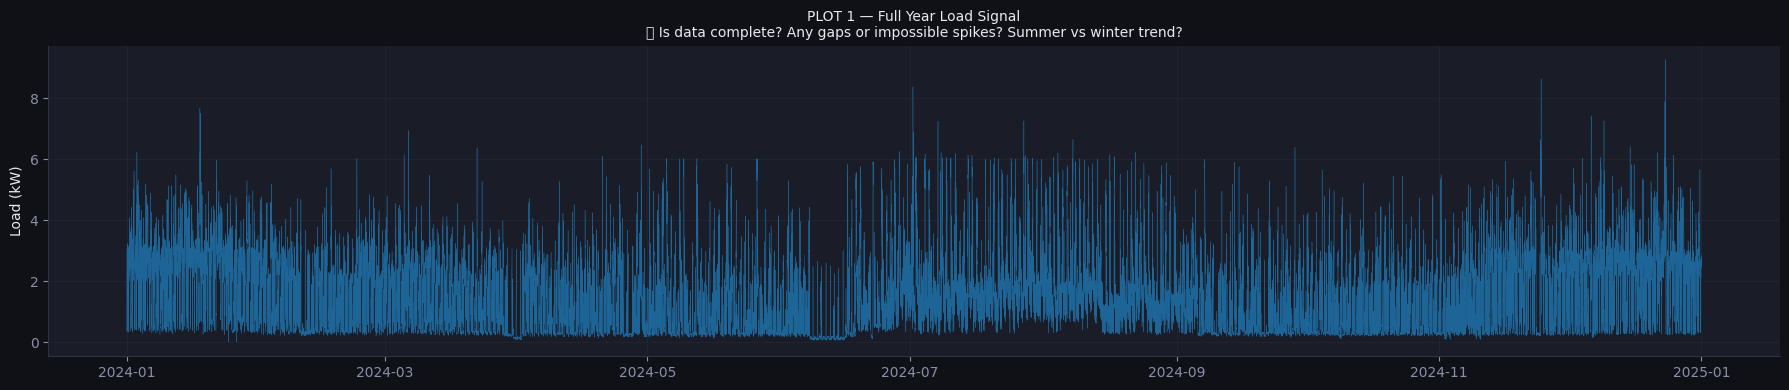

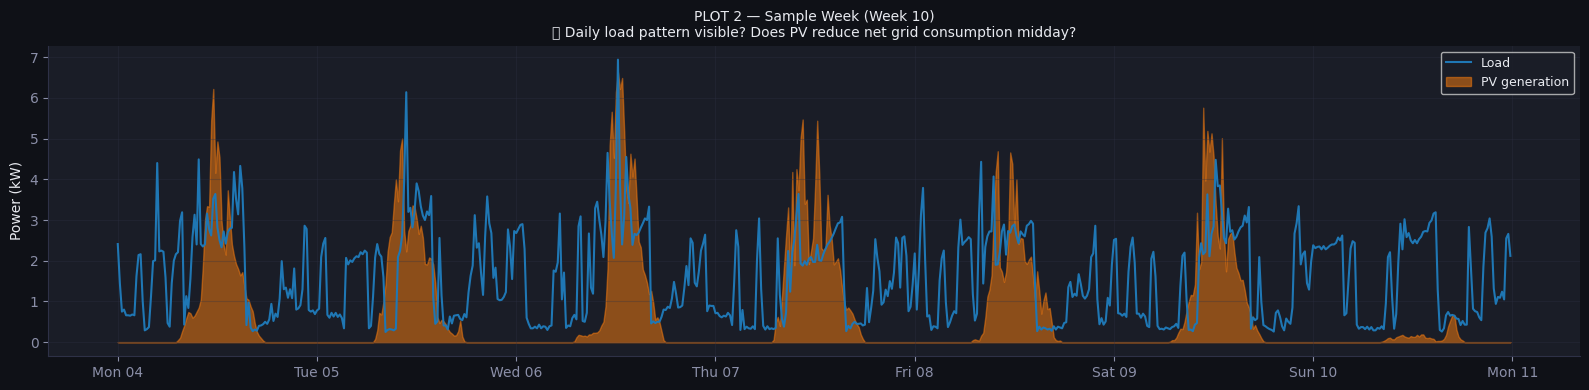

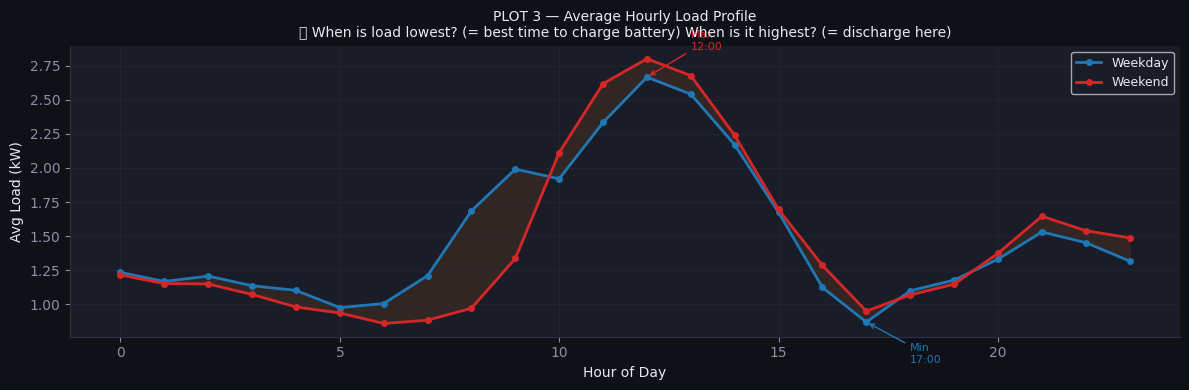

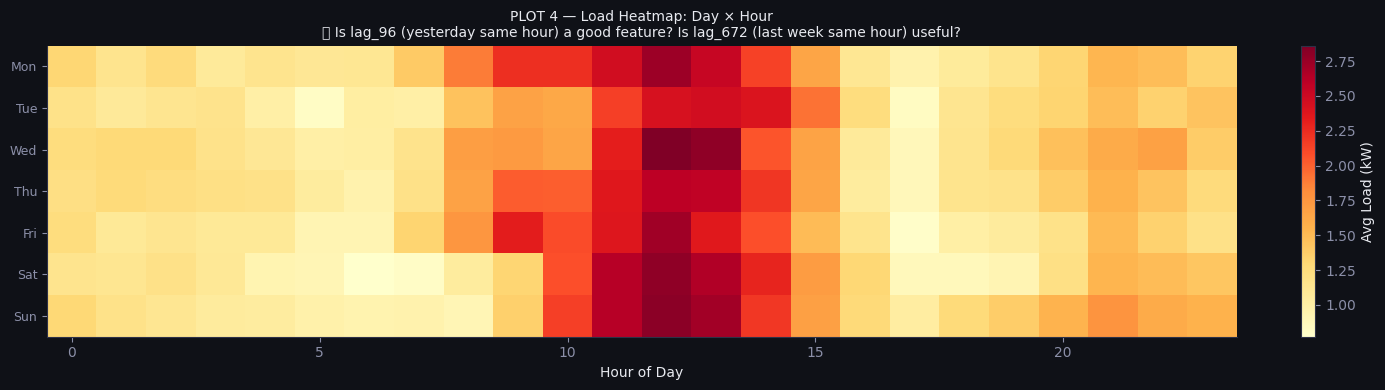

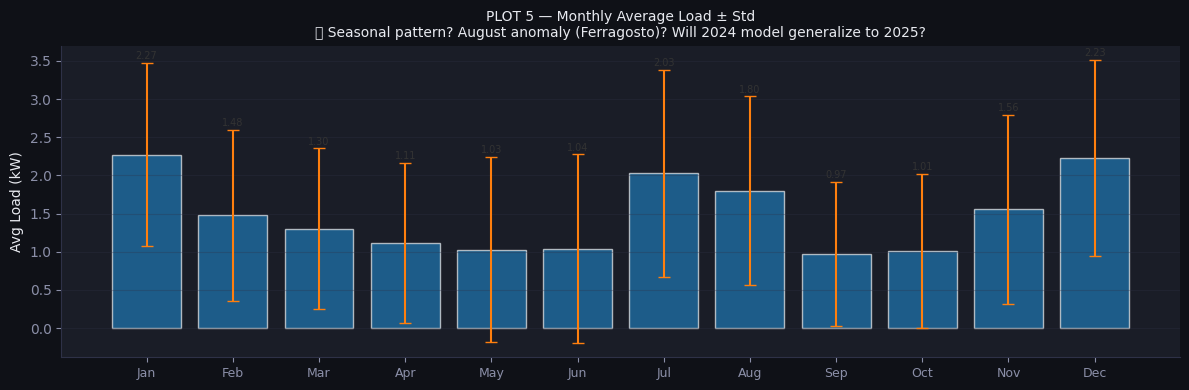

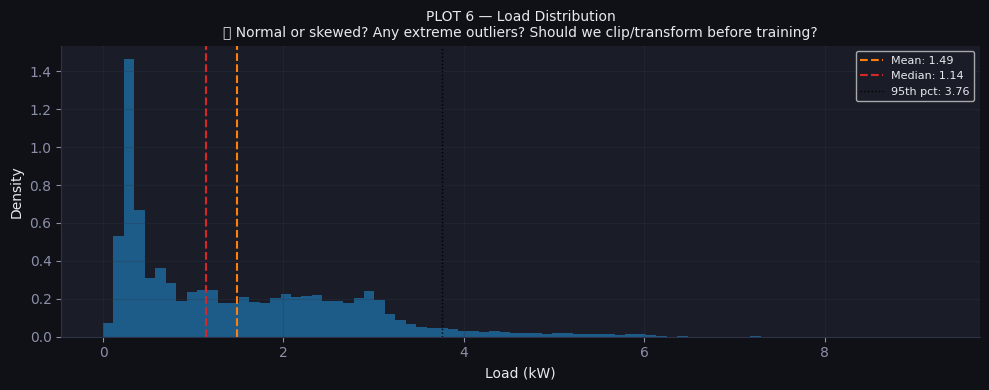

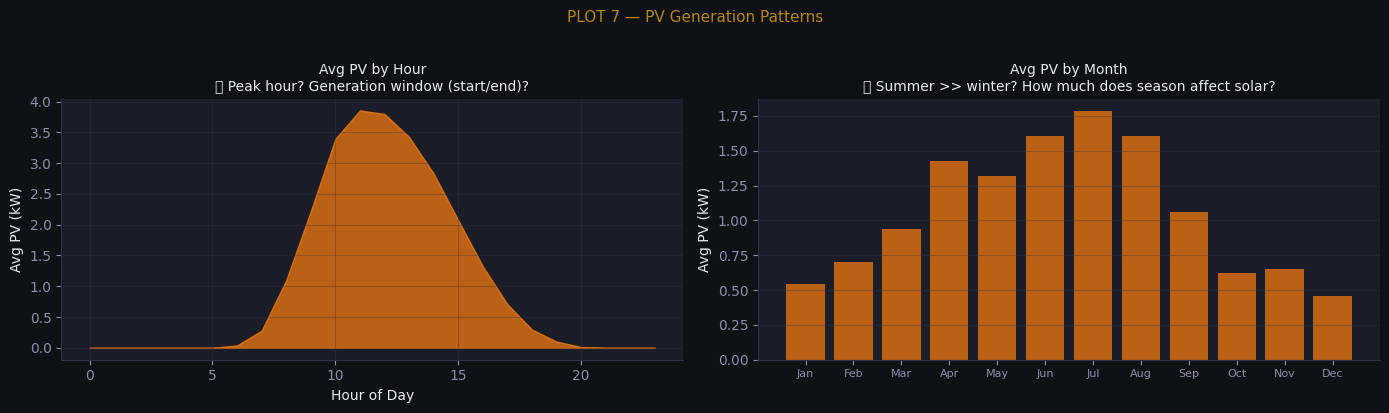

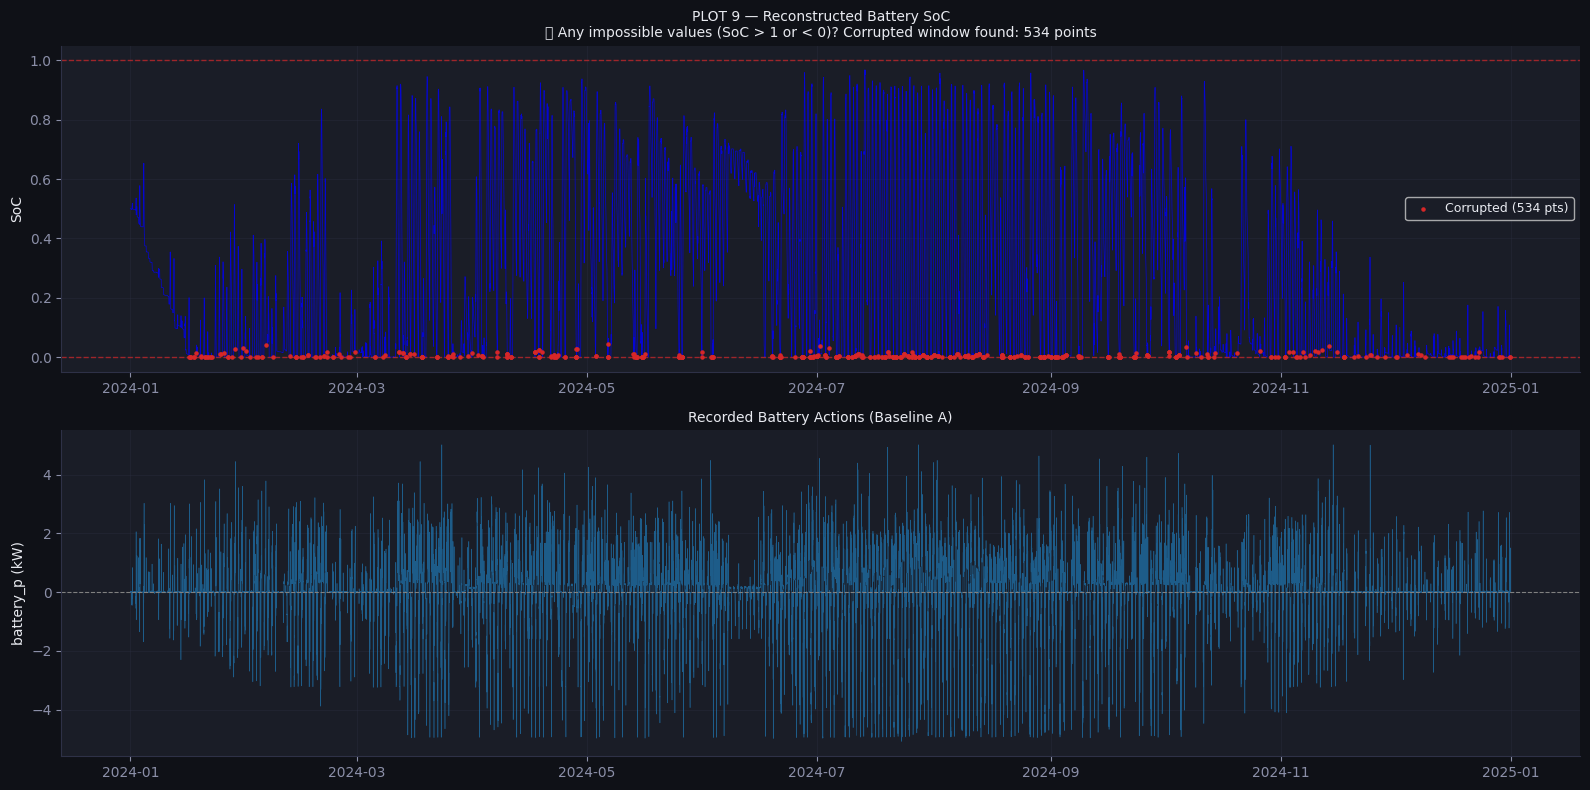


  ⚠️  CORRUPTED DATA DETECTED
     Count : 534 timesteps
     Start : 2024-01-16 15:45:00
     End   : 2024-12-31 19:00:00
     Action: these will be zeroed for Baseline A

✅ EDA complete for 2024
   Read the ❓ question on each plot and write your answers.
   Those answers = your feature engineering decisions.


In [303]:
# Run on 2024 first (training data)
explore_dataset(df_2024, year_label='2024')

#Feature Engineering

Occupied periods : 34,122 rows (97.1%)
Empty periods    : 1,010 rows (2.9%)

Occupied load  → mean: 1.52 kW  max: 9.26 kW
Empty load     → mean: 0.48 kW    max: 5.52 kW


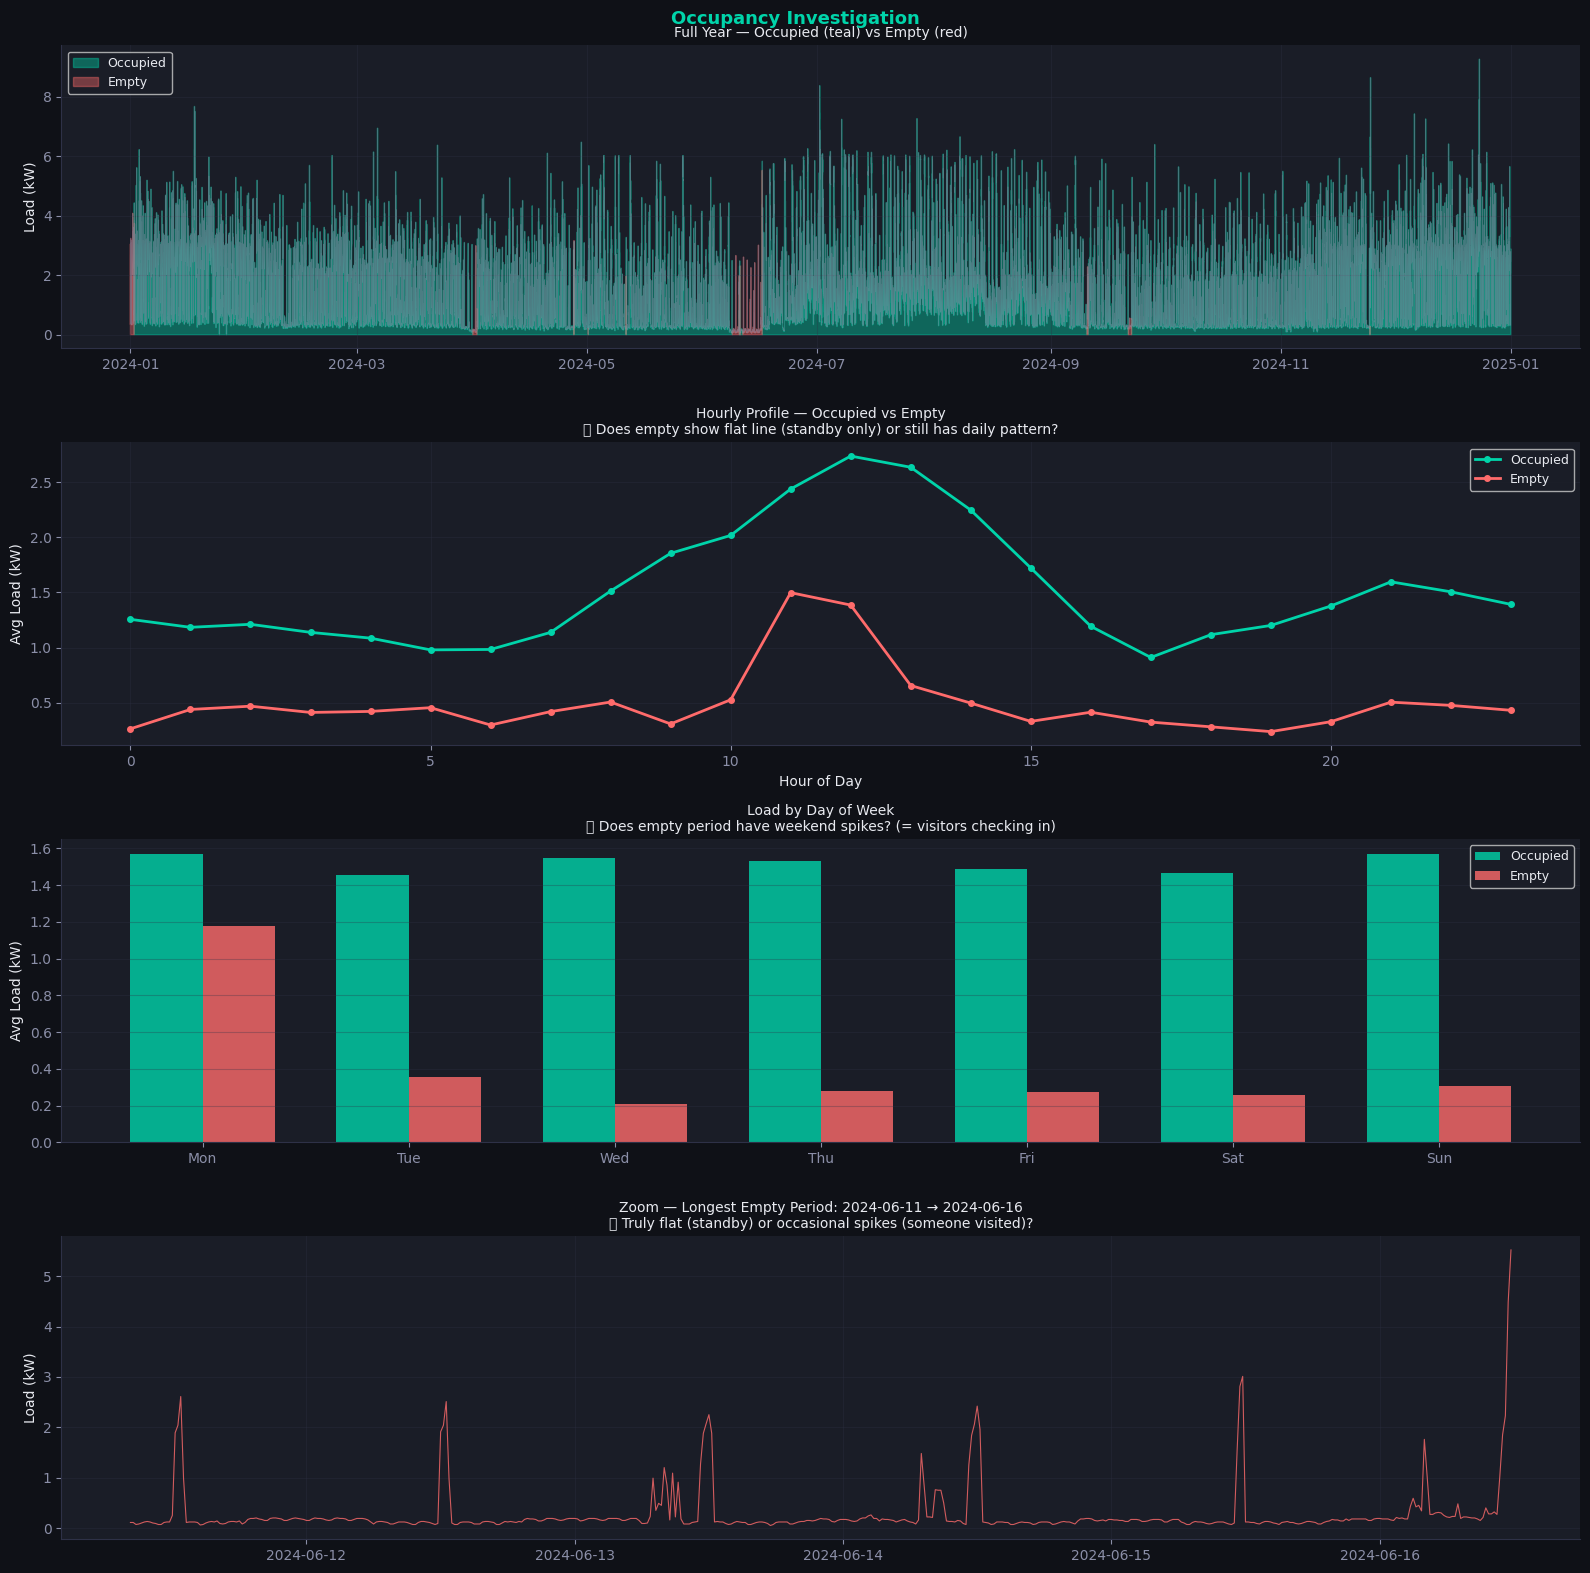

In [304]:
# Define color variables (copied from _60ECfzVAzsf for scope)
TEAL = '#00d4aa'
RED  = '#ff6b6b'
GOLD = '#ffd93d'
BLUE = '#4a9eff'
GREY = '#8b8fa8'
BG   = '#0f1117'
PANEL= '#1a1d27'

# Add time-based features to df_2024 (as done in explore_dataset)
df_2024['hour']  = df_2024['timestamp'].dt.hour
df_2024['dow']   = df_2024['timestamp'].dt.dayofweek
df_2024['month'] = df_2024['timestamp'].dt.month
df_2024['date']  = df_2024['timestamp'].dt.date

# ── Step 1: Define occupied vs empty based on rolling mean ─────
df_2024['rolling_mean_24h'] = df_2024['load_p'].rolling(96).mean()
df_2024['is_occupied']      = (df_2024['rolling_mean_24h'] > 0.4).astype(int)

occupied = df_2024[df_2024['is_occupied'] == 1]
empty    = df_2024[df_2024['is_occupied'] == 0]

print(f"Occupied periods : {len(occupied):,} rows ({len(occupied)/len(df_2024)*100:.1f}%)")
print(f"Empty periods    : {len(empty):,} rows ({len(empty)/len(df_2024)*100:.1f}%)")
print(f"\nOccupied load  → mean: {occupied['load_p'].mean():.2f} kW  max: {occupied['load_p'].max():.2f} kW")
print(f"Empty load     → mean: {empty['load_p'].mean():.2f} kW    max: {empty['load_p'].max():.2f} kW")

# ── Step 2: Four plots ─────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 16))
fig.suptitle('Occupancy Investigation', fontsize=13, color=TEAL, fontweight='bold')

# Plot A — Full year colored by occupancy
ax = axes[0]
ax.plot(df_2024['timestamp'], df_2024['load_p'], color=GREY, lw=0.3, alpha=0.5)
ax.fill_between(df_2024['timestamp'], df_2024['load_p'],
                where=df_2024['is_occupied']==1, color=TEAL, alpha=0.4, label='Occupied')
ax.fill_between(df_2024['timestamp'], df_2024['load_p'],
                where=df_2024['is_occupied']==0, color=RED,  alpha=0.4, label='Empty')
ax.set_title('Full Year — Occupied (teal) vs Empty (red)', fontsize=10)
ax.set_ylabel('Load (kW)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot B — Hourly profile: occupied vs empty
ax2 = axes[1]
occ_hour   = occupied.groupby('hour')['load_p'].mean()
empty_hour = empty.groupby('hour')['load_p'].mean()
ax2.plot(occ_hour.index,   occ_hour.values,   color=TEAL, lw=2, marker='o', ms=4, label='Occupied')
ax2.plot(empty_hour.index, empty_hour.values, color=RED,  lw=2, marker='o', ms=4, label='Empty')
ax2.set_title('Hourly Profile — Occupied vs Empty\n'
              '❓ Does empty show flat line (standby only) or still has daily pattern?', fontsize=10)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Avg Load (kW)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot C — Day of week: occupied vs empty
ax3 = axes[2]
occ_dow   = occupied.groupby('dow')['load_p'].mean()
empty_dow = empty.groupby('dow')['load_p'].mean()
x = range(7)
w = 0.35
ax3.bar([i - w/2 for i in x], occ_dow.values,   width=w, color=TEAL, alpha=0.8, label='Occupied')
ax3.bar([i + w/2 for i in x], empty_dow.values,  width=w, color=RED,  alpha=0.8, label='Empty')
ax3.set_xticks(range(7))
ax3.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax3.set_title('Load by Day of Week\n'
              '❓ Does empty period have weekend spikes? (= visitors checking in)', fontsize=10)
ax3.set_ylabel('Avg Load (kW)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# Plot D — Zoom into one empty period
# Find the longest continuous empty stretch
df_2024['empty_block'] = (df_2024['is_occupied'] != df_2024['is_occupied'].shift()).cumsum()
empty_blocks = df_2024[df_2024['is_occupied']==0].groupby('empty_block')['timestamp'].agg(['min','max','count'])
longest = empty_blocks.sort_values('count', ascending=False).iloc[0]

zoom = df_2024[(df_2024['timestamp'] >= longest['min']) &
               (df_2024['timestamp'] <= longest['max'])]

ax4 = axes[3]
ax4.plot(zoom['timestamp'], zoom['load_p'], color=RED, lw=0.8, alpha=0.8)
ax4.set_title(f'Zoom — Longest Empty Period: {longest["min"].date()} → {longest["max"].date()}\n'
              f'❓ Truly flat (standby) or occasional spikes (someone visited)?', fontsize=10)
ax4.set_ylabel('Load (kW)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('occupancy_investigation.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()

Generating ACF and PACF plots for 'load_p'...


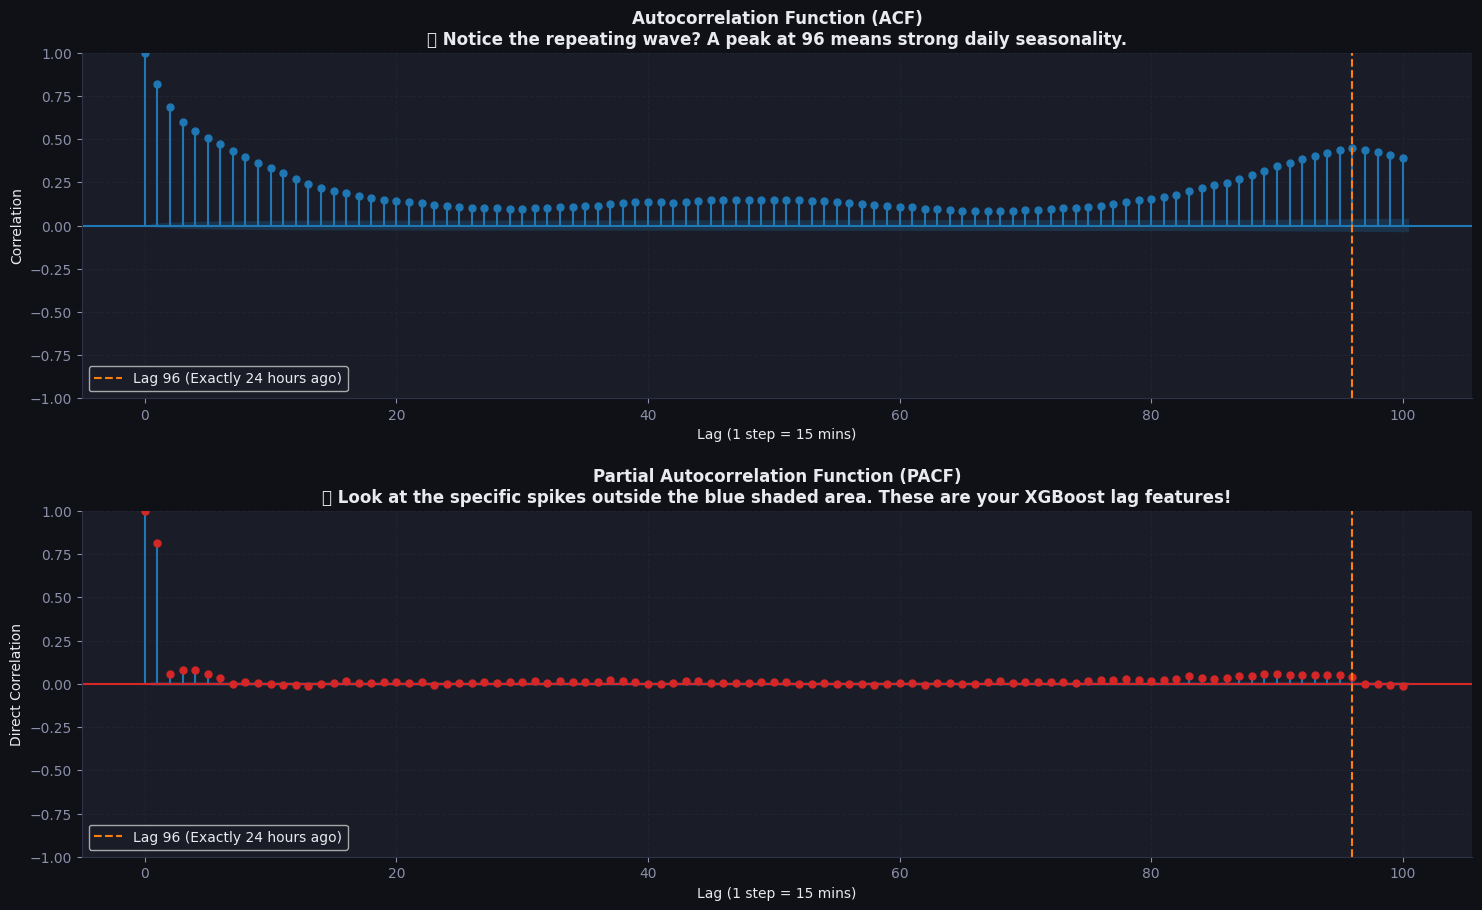

In [305]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(df, target_col='load_p', lags=100):
    """
    Plots ACF and PACF to identify the best lag features for XGBoost.
    lags=100 will cover just over 24 hours (96 timesteps = 1 day).
    """
    print(f"Generating ACF and PACF plots for '{target_col}'...")

    # Drop NaNs just in case, as statsmodels will throw an error
    series = df[target_col].dropna()

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.tight_layout(pad=6.0)

    # ---------------------------------------------------------
    # 1. ACF Plot
    # ---------------------------------------------------------
    plot_acf(series, ax=axes[0], lags=lags, color='#1f77b4', alpha=0.05)
    axes[0].set_title('Autocorrelation Function (ACF)\n'
                      '❓ Notice the repeating wave? A peak at 96 means strong daily seasonality.',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Lag (1 step = 15 mins)')
    axes[0].set_ylabel('Correlation')
    axes[0].grid(True, linestyle='--', alpha=0.3)

    # Highlight the 24-hour mark (lag 96)
    axes[0].axvline(x=96, color='#ff7f0e', linestyle='--', lw=1.5, label='Lag 96 (Exactly 24 hours ago)')
    axes[0].legend()

    # ---------------------------------------------------------
    # 2. PACF Plot
    # ---------------------------------------------------------
    # method='ywm' is generally faster and more stable for large time-series
    plot_pacf(series, ax=axes[1], lags=lags, method='ywm', color='#d62728', alpha=0.05)
    axes[1].set_title('Partial Autocorrelation Function (PACF)\n'
                      '❓ Look at the specific spikes outside the blue shaded area. These are your XGBoost lag features!',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Lag (1 step = 15 mins)')
    axes[1].set_ylabel('Direct Correlation')
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # Highlight the 24-hour mark (lag 96)
    axes[1].axvline(x=96, color='#ff7f0e', linestyle='--', lw=1.5, label='Lag 96 (Exactly 24 hours ago)')
    axes[1].legend()

    plt.savefig('acf_pacf_plots.png', dpi=120, bbox_inches='tight', facecolor='white')
    plt.show()



# Run the function on your 2024 data
# Make sure df_2024 is defined and timestamp is sorted!
df_2024 = df_2024.sort_values('timestamp')
plot_acf_pacf(df_2024, target_col='load_p', lags=100)

In [307]:
def engineer_features(df, weather_df, holiday_df, use_weather=True):
    """
    Build LEAN, highly predictive features for XGBoost.
    """
    df = df.copy().sort_values('timestamp').reset_index(drop=True)

    # ── 1. CALENDAR FEATURES ───────────────────────────────────
    df['hour']       = df['timestamp'].dt.hour
    df['dow']        = df['timestamp'].dt.dayofweek
    df['month']      = df['timestamp'].dt.month
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['is_midday']  = df['hour'].between(10, 14).astype(int) # Good for solar peaks

    # ── 2. CYCLICAL ENCODING ───────────────────────────────────
    df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # ── 3. HOLIDAYS ────────────────────────────────────────────
    holiday_dates = set(holiday_df['date'].dt.date)
    df['is_holiday'] = df['timestamp'].dt.date.map(lambda d: 1 if d in holiday_dates else 0)

    # ── 4. STABLE LAGS & MEMORY (No short-term leaks) ──────────
    df['lag_96']  = df['load_p'].shift(96)  # Yesterday
    df['lag_192'] = df['load_p'].shift(192) # 2 days ago
    df['lag_288'] = df['load_p'].shift(288) # 3 days ago
    df['lag_672'] = df['load_p'].shift(672) # Last week

    # Highly stable baseline: average of the same exact hour over the last 3 days
    df['lag_mean_3d'] = df[['lag_96', 'lag_192', 'lag_288']].mean(axis=1)

    # Smooth 24h trailing average to detect "vacation mode" or standby
    df['rolling_mean_24h'] = df['load_p'].shift(1).rolling(96).mean()
    df['is_standby'] = (df['rolling_mean_24h'] < 0.4).astype(int)

    # ── 5. WEATHER FEATURES ────────────────────────────────────
    if use_weather:
        # Ensure timestamps are consistent for merging
        weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp']).dt.round('15min')
        df['timestamp']         = pd.to_datetime(df['timestamp']).dt.round('15min')

        # Drop existing weather columns to avoid suffixes in merge
        # These columns would only exist for the df_2024 portion of df_combined,
        # but we want to merge fresh from weather_df for all timestamps.
        df = df.drop(columns=['temperature_2m', 'solar_irradiance'], errors='ignore')

        # Perform the merge
        df = df.merge(weather_df[['timestamp', 'temperature_2m', 'solar_irradiance']], on='timestamp', how='left')

        # Core physical drivers
        df['heating_degrees'] = np.maximum(18 - df['temperature_2m'], 0)
        df['cooling_degrees'] = np.maximum(df['temperature_2m'] - 24, 0)
        df['cloud_factor']    = np.clip(df['solar_irradiance'] / 900, 0, 1)

        # Weather proxy for sudden human action (e.g., sun drops -> turn on lights)
        df['solar_drop_15m'] = df['solar_irradiance'].shift(1) - df['solar_irradiance']
        df['solar_drop_15m'] = df['solar_drop_15m'].fillna(0)

    return df


# ── Define feature columns ─────────────────────────────────────
# The previous FEATURE_COLS_WITH_WEATHER and FEATURE_COLS_NO_WEATHER lists
# were outdated and contained features no longer generated by engineer_features.
# The SAFE_FEATURES list from the next cell (cjxpUj0Yue21) represents the
# intended lean and highly predictive features for the model.

# Defining SAFE_FEATURES here to ensure consistency and resolve KeyError.
SAFE_FEATURES = [
    'lag_mean_3d',      # Strongest feature: what normally happens at this time
    'lag_96',           # Yesterday's specific noise
    'lag_672',          # Last week's specific noise

    'hour_cos',         # Daily cycle
    'month_cos',        # Yearly cycle
    'is_weekend',       # Behavioral shift
    'is_holiday',       # Behavioral override
    'is_midday',        # Solar/lunch overlap
    'is_standby',       # Baseline context

    'temperature_2m',   # Raw temp
    'heating_degrees',  # Non-linear cold response
    'cooling_degrees',  # Non-linear hot response
    'cloud_factor',     # Smooth sunlight
    'solar_drop_15m'    # Sudden lighting needs
]

# For cases without weather data (e.g., surprise dataset), only non-weather features are used.
# This list is updated to reflect only generated features that are not weather-dependent.
FEATURE_COLS_NO_WEATHER = [
    'lag_mean_3d',
    'lag_96',
    'lag_672',
    'hour', 'dow', 'month',
    'is_weekend', 'is_holiday', 'is_midday',
    'hour_cos', 'month_cos',
    'rolling_mean_24h', 'is_standby',
]

TARGET_COL = 'load_p'


# Fetch weather and holidays (run once, reuse)
weather_df  = fetch_sondrio_weather()
holiday_df  = generate_italian_holidays()

# SET  TEST WINDOW HERE
TEST_START = '2025-09-01'   # first day of test month
TEST_END   = '2025-10-01'   # first day after test month

# Combine into one continuous timeline so lags cross the year boundary correctly
df_combined = pd.concat([df_2024, df_2025]).sort_values('timestamp').reset_index(drop=True)
df_combined_feat = engineer_features(df_combined, weather_df, holiday_df, use_weather=True)

# Split AFTER engineering — training is everything strictly before TEST_START
df_train_feat = df_combined_feat[df_combined_feat['timestamp'] < TEST_START].copy()
df_test_feat  = df_combined_feat[
    (df_combined_feat['timestamp'] >= TEST_START) &
    (df_combined_feat['timestamp'] <  TEST_END)
].copy().reset_index(drop=True)

# Drop NaNs only from training (first 7 days lose lag_672 — fine)
df_train_feat = df_train_feat.dropna(subset=SAFE_FEATURES + [TARGET_COL])
# Test set keeps its rows even if early ones have NaN lags (the recursive loop overwrites them anyway)

print(f"Train: {len(df_train_feat):,} rows  (up to {TEST_START})")
print(f"Test : {len(df_test_feat):,} rows  ({TEST_START} → {TEST_END})")

Fetching hourly weather data for Sondrio and interpolating to 15-min...
Success! Interpolated down to 70173 15-minute rows.
Generating Italian public holidays for 2024 and 2025...
Success! Found 26 holidays.
Train: 57,788 rows  (up to 2025-09-01)
Test : 2,880 rows  (2025-09-01 → 2025-10-01)


#Model


Initializing Safe Batch Forecaster...
Train : 51,836 rows
Val   : 5,952 rows
[0]	validation_0-rmse:1.27263
[100]	validation_0-rmse:0.98271
[147]	validation_0-rmse:0.98583

Best iteration: 97

── Validation Metrics (Nov–Dec 2024) ──
  RMSE  = 0.9817 kW
  MAE   = 0.7163 kW
  NRMSE = 75.47%

Predicting Test Set...

── Top 10 Most Important Features ──
lag_mean_3d        0.2425
is_midday          0.2054
lag_96             0.0875
lag_672            0.0649
is_standby         0.0591
hour_cos           0.0575
month_cos          0.0519
cloud_factor       0.0455
cooling_degrees    0.0418
heating_degrees    0.0410


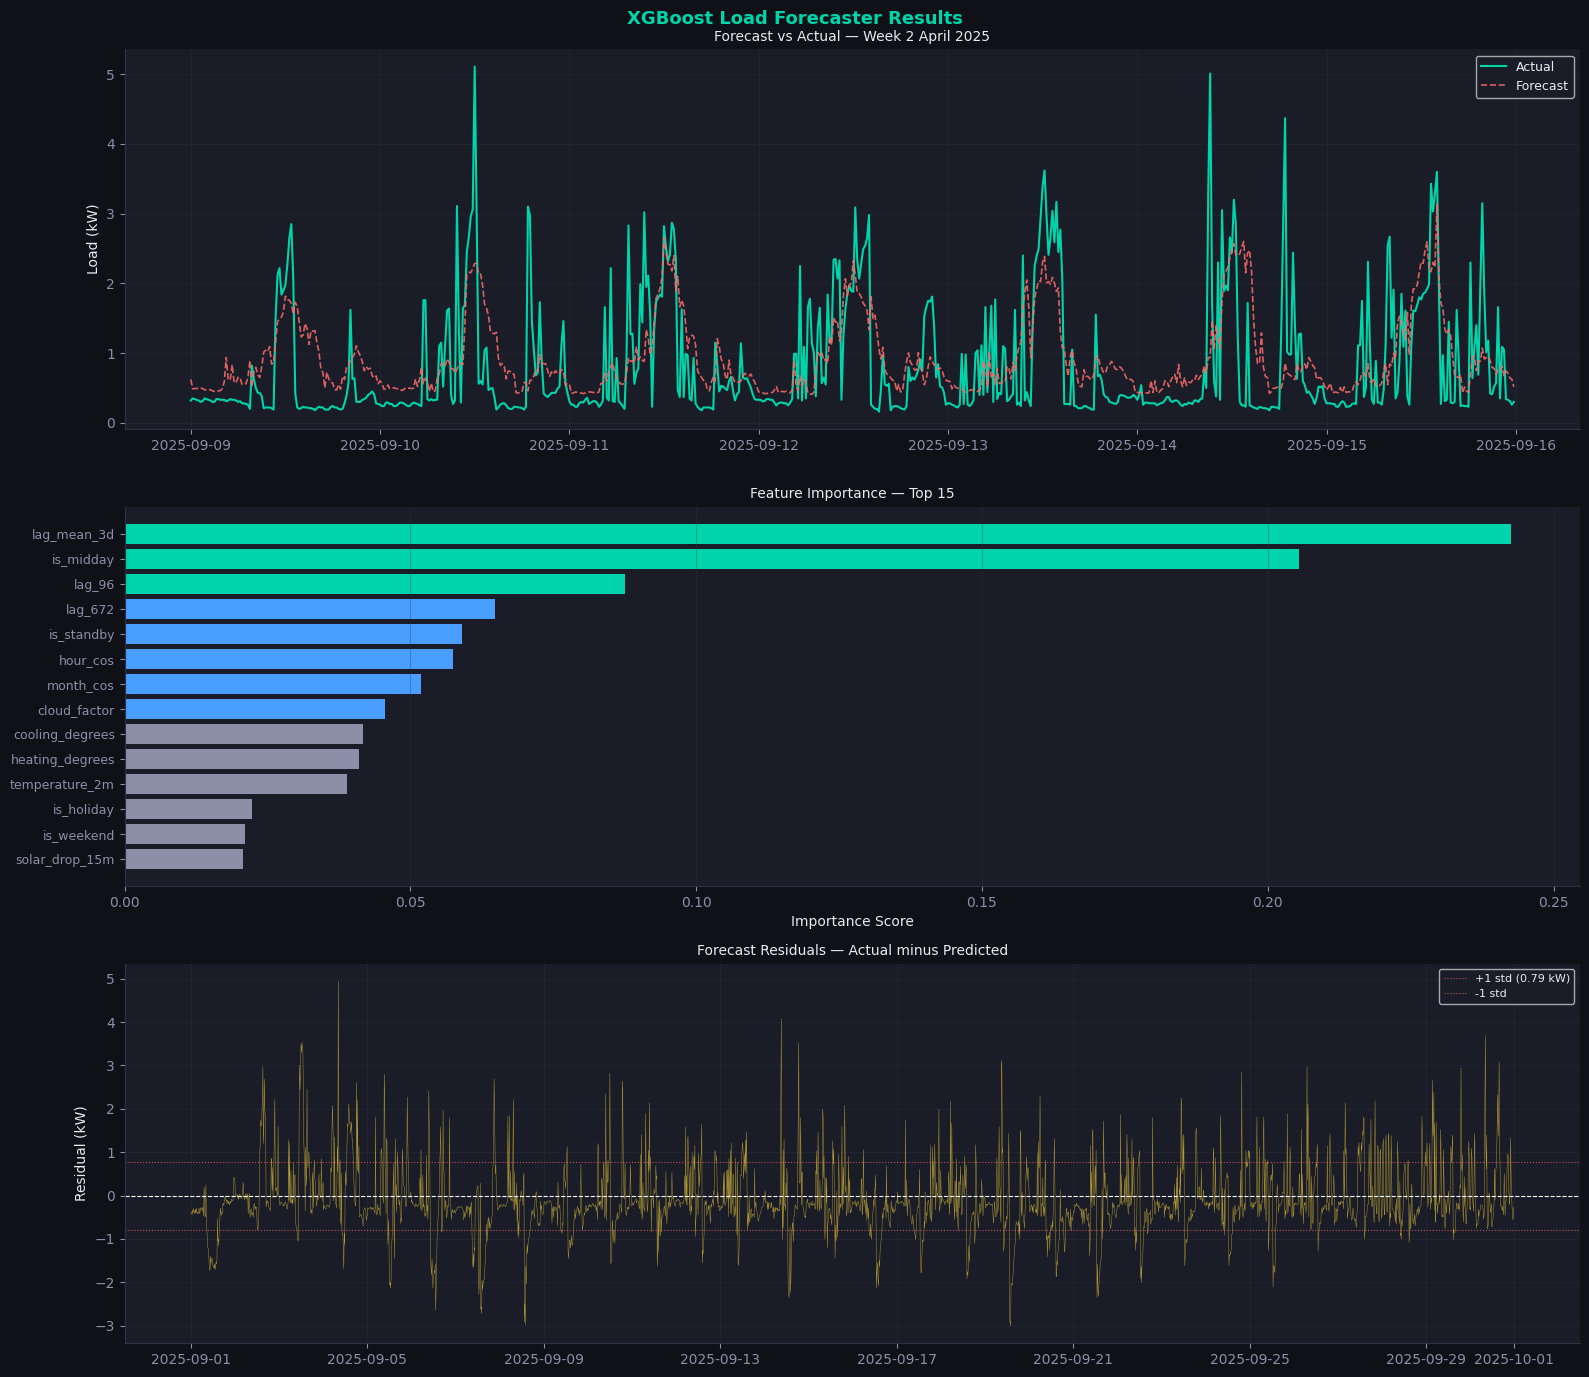


  DAY 1 SUBMISSION — BATCH FORECAST
  RMSE  = 0.7952 kW
  MAE   = 0.5704 kW
  NRMSE = 94.87%
Corrected NRMSE: 94.84%


In [310]:
# ================================================================
# XGBOOST LOAD FORECASTER (SAFE BATCH INFERENCE)
# ================================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Initializing Safe Batch Forecaster...")



# ── 1. TRAIN / VALIDATION SPLIT ───────────────────────────────
val_start  = pd.Timestamp(TEST_START) - pd.DateOffset(months=2)

train = df_train_feat[df_train_feat['timestamp'] < val_start].copy()
val   = df_train_feat[df_train_feat['timestamp'] >= val_start].copy()

X_train = train[SAFE_FEATURES]
y_train = train[TARGET_COL]
X_val   = val[SAFE_FEATURES]
y_val   = val[TARGET_COL]

print(f"Train : {len(X_train):,} rows")
print(f"Val   : {len(X_val):,} rows")

# ── 2. TRAIN XGBOOST ──────────────────────────────────────────
model = xgb.XGBRegressor(
    n_estimators          = 1500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.5,
    min_child_weight      = 5,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    early_stopping_rounds = 50,
    random_state          = 42,
    n_jobs                = -1,
    objective             = 'reg:squarederror'
)

model.fit(
    X_train, y_train,
    eval_set      = [(X_val, y_val)],
    verbose       = 100,
)

print(f"\nBest iteration: {model.best_iteration}")

# ── 3. EVALUATE ON VALIDATION (Nov–Dec 2024) ──────────────────
val_pred = np.maximum(model.predict(X_val), 0)

rmse_val  = np.sqrt(mean_squared_error(y_val, val_pred))
mae_val   = mean_absolute_error(y_val, val_pred)
nrmse_val = rmse_val / y_val.mean() * 100

print(f"\n── Validation Metrics (Nov–Dec 2024) ──")
print(f"  RMSE  = {rmse_val:.4f} kW")
print(f"  MAE   = {mae_val:.4f} kW")
print(f"  NRMSE = {nrmse_val:.2f}%")

# ── 4. BATCH INFERENCE ON TEST SET (FAST & SAFE) ──────────────
print("\nPredicting Test Set...")

# Optional: You can uncomment these two lines to retrain on 100% of 2024 for max accuracy
# model.n_estimators = model.best_iteration
# model.fit(df_train_feat[SAFE_FEATURES], df_train_feat[TARGET_COL])

X_test_vals = df_test_feat[SAFE_FEATURES]
pred_out    = np.maximum(model.predict(X_test_vals), 0)

# Save predictions to the test dataframe
df_test_feat['load_forecast'] = pred_out
y_test = df_test_feat[TARGET_COL].values

# Map variables for plotting
df_2025_feat = df_test_feat.copy()
pred_2025    = pred_out
y_2025       = y_test

rmse_2025  = np.sqrt(mean_squared_error(y_2025, pred_2025))
mae_2025   = mean_absolute_error(y_2025, pred_2025)
nrmse_2025 = rmse_2025 / y_2025.mean() * 100

# ── 5. FEATURE IMPORTANCE ─────────────────────────────────────
feat_imp = pd.Series(
    model.feature_importances_,
    index=SAFE_FEATURES
).sort_values(ascending=False)

print(f"\n── Top 10 Most Important Features ──")
print(feat_imp.head(10).round(4).to_string())

# ── 6. PLOTS ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('XGBoost Load Forecaster Results', fontsize=13,
             color='#00d4aa', fontweight='bold')

# Plot A — Forecast vs Actual
week3 = df_2025_feat[
    (df_2025_feat['timestamp'] >= '2025-09-09') &
    (df_2025_feat['timestamp'] <  '2025-09-16')
]
axes[0].plot(week3['timestamp'], week3['load_p'],
             color='#00d4aa', lw=1.5, label='Actual')
axes[0].plot(week3['timestamp'], week3['load_forecast'],
             color='#ff6b6b', lw=1.2, ls='--', label='Forecast', alpha=0.85)
axes[0].set_title('Forecast vs Actual — Week 2 April 2025', fontsize=10)
axes[0].set_ylabel('Load (kW)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot B — Feature importance (top 15)
top15 = feat_imp.head(15)
colors = ['#00d4aa' if i < 3 else '#4a9eff' if i < 8 else '#8b8fa8'
          for i in range(len(top15))]
axes[1].barh(range(len(top15)), top15.values[::-1], color=colors[::-1])
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels(top15.index[::-1], fontsize=9)
axes[1].set_title('Feature Importance — Top 15', fontsize=10)
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3, axis='x')

# Plot C — Residuals
residuals = y_2025 - pred_2025

axes[2].plot(df_2025_feat['timestamp'], residuals,
             color='#ffd93d', lw=0.3, alpha=0.7)
axes[2].axhline(0, color='white', lw=0.8, ls='--')
axes[2].axhline( residuals.std(), color='#ff6b6b', lw=0.8, ls=':', alpha=0.7,
                 label=f'+1 std ({residuals.std():.2f} kW)')
axes[2].axhline(-residuals.std(), color='#ff6b6b', lw=0.8, ls=':', alpha=0.7,
                 label=f'-1 std')
axes[2].set_title('Forecast Residuals — Actual minus Predicted', fontsize=10)
axes[2].set_ylabel('Residual (kW)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('forecaster_results.png', dpi=120,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ── 7. METRICS SUMMARY ────────────────────────────────────────
print("\n" + "="*50)
print("  DAY 1 SUBMISSION — BATCH FORECAST")
print("="*50)
print(f"  RMSE  = {rmse_2025:.4f} kW")
print(f"  MAE   = {mae_2025:.4f} kW")
print(f"  NRMSE = {nrmse_2025:.2f}%")
print("="*50)

# ── 8. CORRECTION LOGIC ───────────────────────────────────────
pred_2025_corrected = pred_2025.copy()

# Where recent actual load confirms standby → cap prediction
standby_mask = df_2025_feat['is_standby'] == 1
pred_2025_corrected[standby_mask] = np.minimum(
    pred_2025_corrected[standby_mask],
    0.5   # cap at 0.5 kW during standby
)

rmse_corr  = np.sqrt(mean_squared_error(y_2025, pred_2025_corrected))
nrmse_corr = rmse_corr / y_2025.mean() * 100
print(f"Corrected NRMSE: {nrmse_corr:.2f}%")


Predicting and Saving Results for April & September 2025...

Processing April_2025...
  RMSE  = 0.8483 kW
  MAE   = 0.6020 kW
  NRMSE = 87.98%


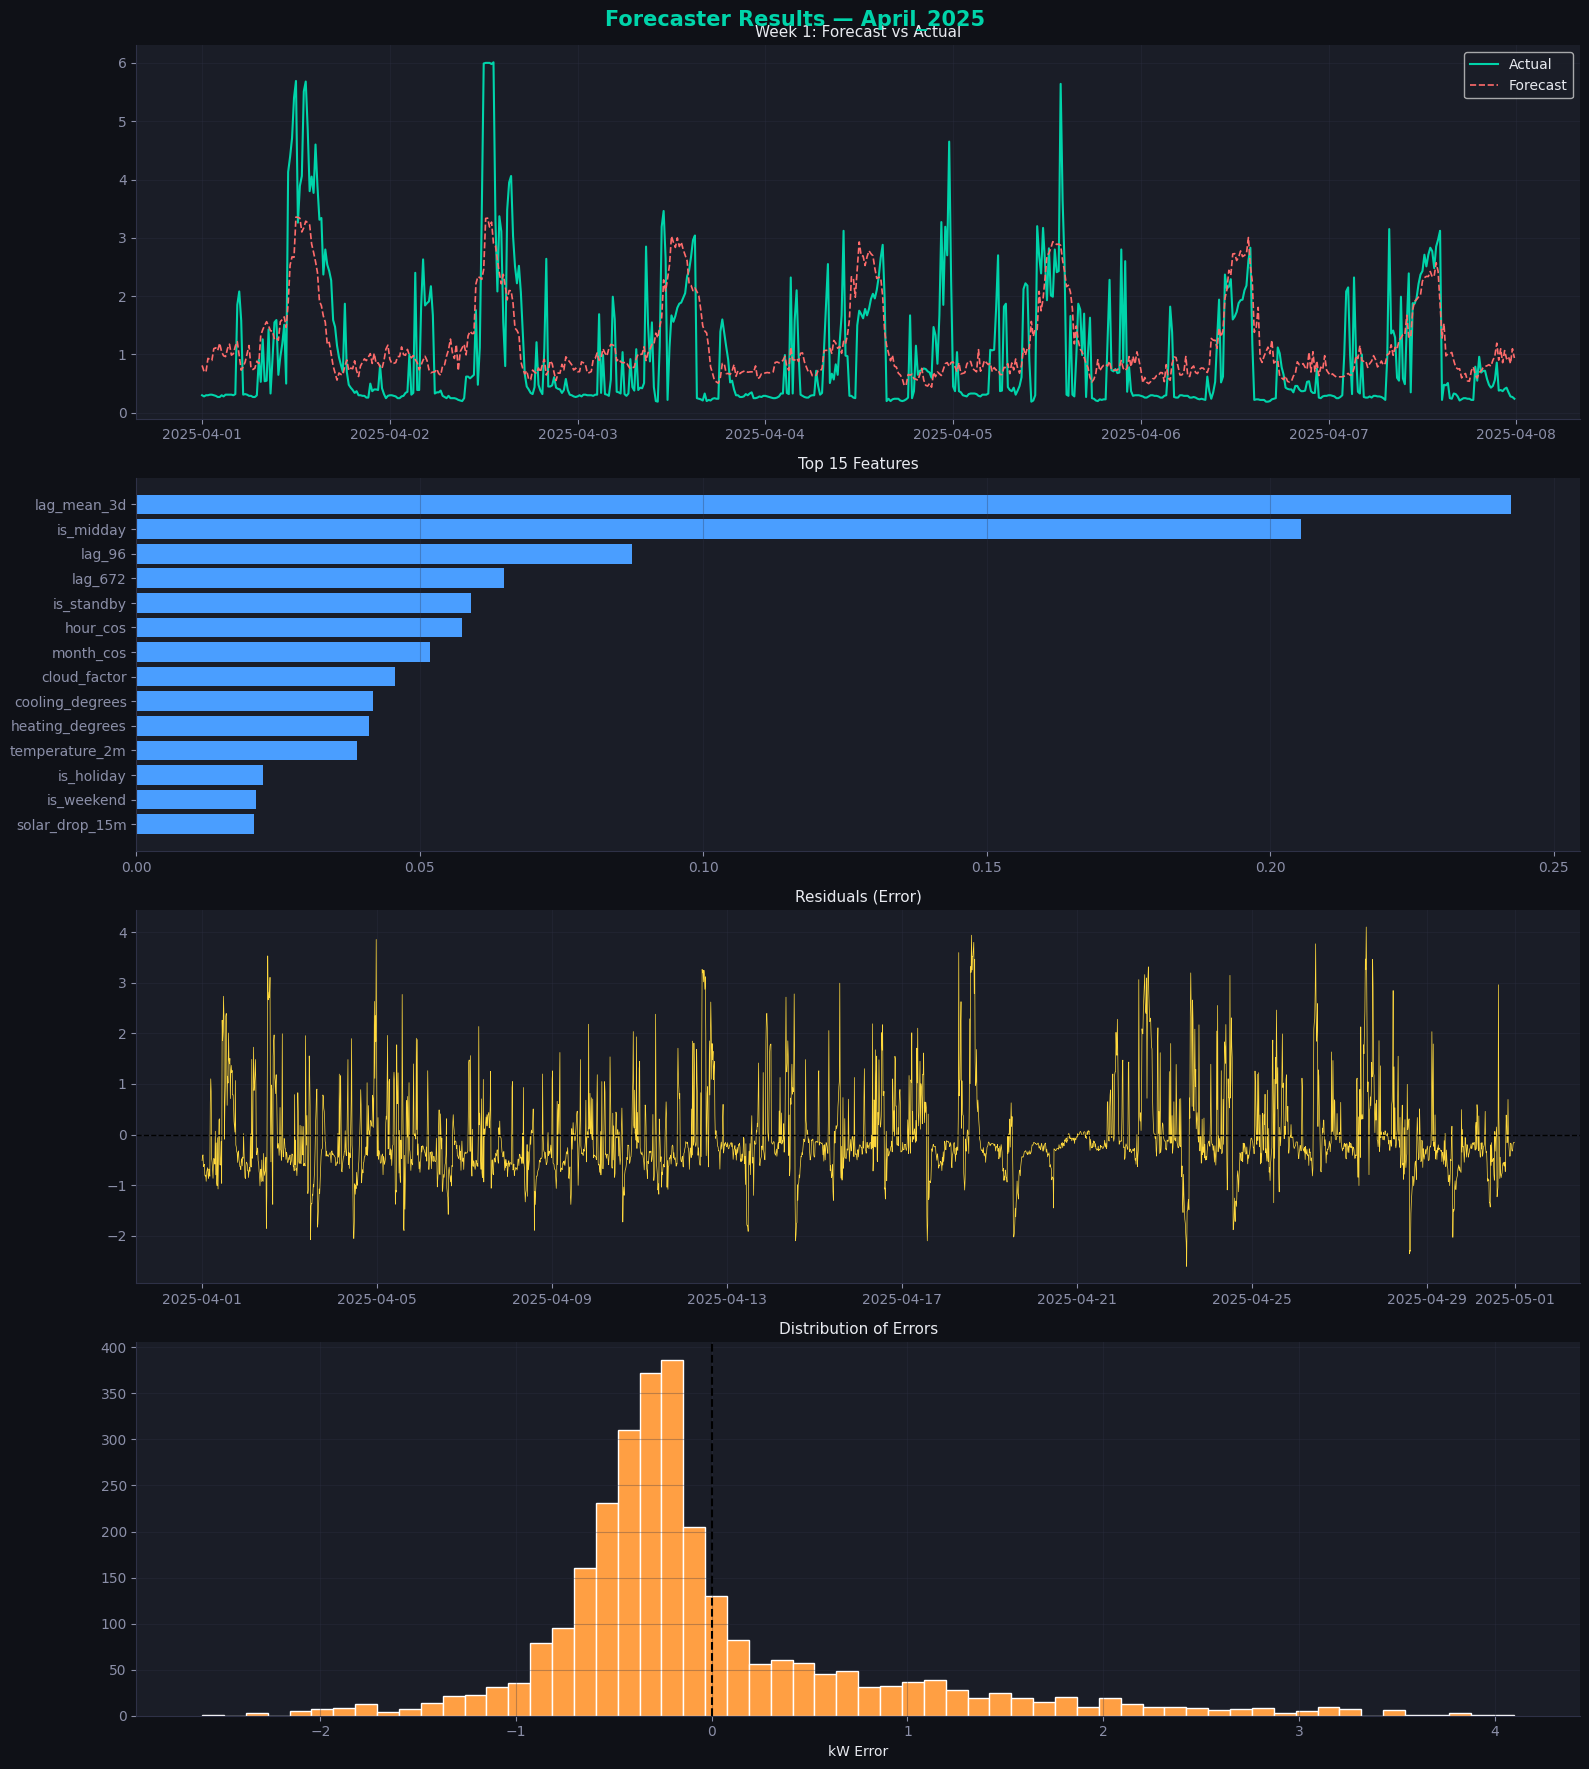


Processing September_2025...
  RMSE  = 0.7949 kW
  MAE   = 0.5690 kW
  NRMSE = 94.84%


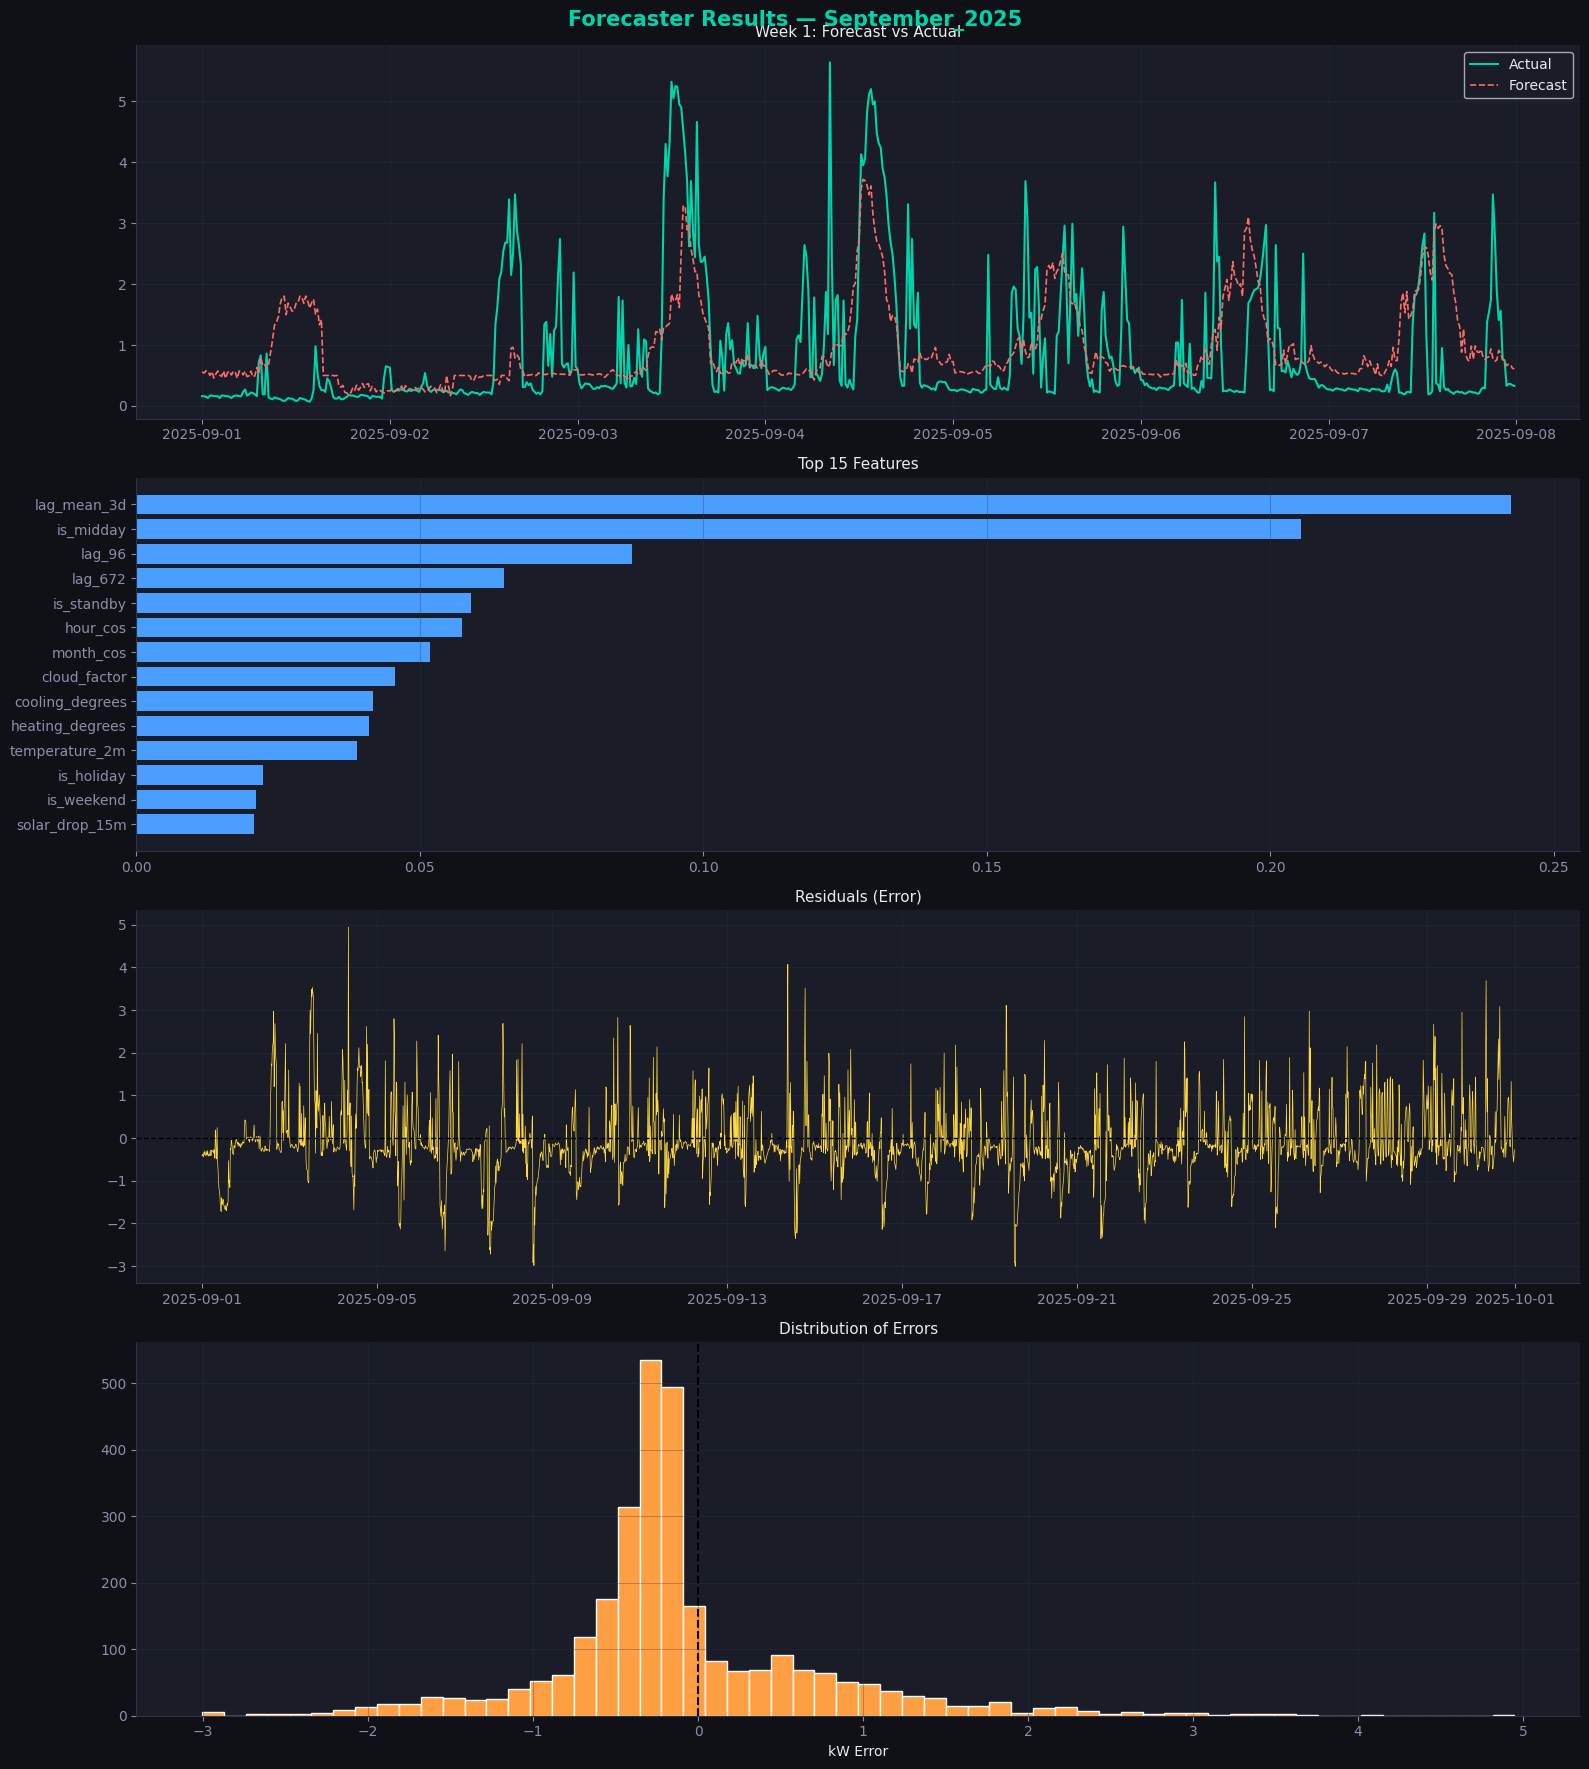


✅ All results and plots saved in: data/output


In [314]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ================================================================
# ── 4. EVALUATION & CSV EXPORT (APRIL & SEPTEMBER) ──────────────
# ================================================================

print("\nPredicting and Saving Results for April & September 2025...")

# 1. Create the output directory safely
output_folder = "data/output"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created directory: {output_folder}")

# Define the two test periods
test_periods = {
    "April_2025": {"start": "2025-04-01", "end": "2025-05-01"},
    "September_2025": {"start": "2025-09-01", "end": "2025-10-01"}
}

for month_label, dates in test_periods.items():
    print(f"\nProcessing {month_label}...")

    # Slice the specific month
    df_month = df_combined_feat[
        (df_combined_feat['timestamp'] >= dates["start"]) &
        (df_combined_feat['timestamp'] < dates["end"])
    ].copy().reset_index(drop=True)

    # Predict and apply standby correction
    X_test_month = df_month[SAFE_FEATURES]
    pred_raw = np.maximum(model.predict(X_test_month), 0)

    standby_mask = df_month['is_standby'] == 1
    pred_raw[standby_mask] = np.minimum(pred_raw[standby_mask], 0.5)

    df_month['load_forecast'] = pred_raw
    df_month['residual'] = df_month['load_p'] - df_month['load_forecast']

    y_real = df_month['load_p'].values
    y_pred = df_month['load_forecast'].values

    # Calculate Metrics
    rmse  = np.sqrt(mean_squared_error(y_real, y_pred))
    mae   = mean_absolute_error(y_real, y_pred)
    nrmse = (rmse / y_real.mean()) * 100

    print(f"  RMSE  = {rmse:.4f} kW")
    print(f"  MAE   = {mae:.4f} kW")
    print(f"  NRMSE = {nrmse:.2f}%")

    # ── SAVE TO CSV (Data and Metrics in the same file) ──────
    csv_filename = os.path.join(output_folder, f"Forecast_Results_{month_label}.csv")

    # Prepare data for export
    export_data = df_month[['timestamp', 'load_p', 'load_forecast', 'residual']].copy()
    export_data.rename(columns={
        'load_p': 'Actual_Load',
        'load_forecast': 'Predicted_Load',
        'residual': 'Error'
    }, inplace=True)

    # Write the time-series data first
    export_data.to_csv(csv_filename, index=False)

    # Append a separator and the metrics at the bottom of the same file
    with open(csv_filename, 'a') as f:
        f.write("\n# --- SUMMARY METRICS ---\n")

    export_metrics = pd.DataFrame({
        'Metric': ['RMSE_kW', 'MAE_kW', 'NRMSE_percent', 'Mean_Actual_Load_kW'],
        'Value': [rmse, mae, nrmse, y_real.mean()]
    })
    export_metrics.to_csv(csv_filename, mode='a', index=False)

    # ── GENERATE DIAGNOSTIC PLOTS ────────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(16, 18))
    fig.suptitle(f'Forecaster Results — {month_label}', fontsize=15, color='#00d4aa', fontweight='bold')

    # A: Forecast vs Actual
    week1_end = pd.to_datetime(dates["start"]) + pd.Timedelta(days=7)
    week1 = df_month[df_month['timestamp'] < week1_end]
    axes[0].plot(week1['timestamp'], week1['load_p'], color='#00d4aa', lw=1.5, label='Actual')
    axes[0].plot(week1['timestamp'], week1['load_forecast'], color='#ff6b6b', lw=1.2, ls='--', label='Forecast')
    axes[0].set_title('Week 1: Forecast vs Actual', fontsize=11); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # B: Feature Importance
    feat_imp = pd.Series(model.feature_importances_, index=SAFE_FEATURES).sort_values(ascending=False).head(15)
    axes[1].barh(range(len(feat_imp)), feat_imp.values[::-1], color='#4a9eff')
    axes[1].set_yticks(range(len(feat_imp))); axes[1].set_yticklabels(feat_imp.index[::-1])
    axes[1].set_title('Top 15 Features', fontsize=11); axes[1].grid(True, alpha=0.3, axis='x')

    # C: Residuals over time
    axes[2].plot(df_month['timestamp'], df_month['residual'], color='#ffd93d', lw=0.5)
    axes[2].axhline(0, color='black', lw=1, ls='--'); axes[2].set_title('Residuals (Error)', fontsize=11)
    axes[2].grid(True, alpha=0.3)

    # D: Error Histogram
    axes[3].hist(df_month['residual'], bins=60, color='#ff9f43', edgecolor='white')
    axes[3].axvline(0, color='black', lw=1.5, ls='--')
    axes[3].set_title('Distribution of Errors', fontsize=11)
    axes[3].set_xlabel('kW Error'); axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, f"plot_{month_label}.png"), dpi=120)
    plt.show()

print(f"\n✅ All results and plots saved in: {output_folder}")

In [ ]:
model_final = xgb.XGBRegressor(
    n_estimators      = model.best_iteration,  # use best iteration found
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.5,
    min_child_weight  = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
)
model_final.fit(df_train_feat[SAFE_FEATURES], df_train_feat[TARGET_COL])
pred_final  = np.maximum(model_final.predict(df_2025_feat[SAFE_FEATURES]), 0)
nrmse_final = np.sqrt(mean_squared_error(y_2025, pred_final)) / y_2025.mean() * 100
print(f"Full 2024 training NRMSE: {nrmse_final:.2f}%")

In [ ]:
# ================================================================
# MODEL SHOOTOUT: Find the Best Algorithm
# ================================================================
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import time

print("Starting Model Shootout. Please wait...\n")

# Use the best_iteration from your previous validation if it exists, otherwise default to 1500
best_iters = model.best_iteration if hasattr(model, 'best_iteration') else 1500

# ── 1. Define the Contenders ──────────────────────────────────
models = {
    "XGBoost": xgb.XGBRegressor(
        n_estimators=best_iters, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.5, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1
    ),

    "LightGBM": lgb.LGBMRegressor(
        n_estimators=best_iters, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.5, min_child_samples=5,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
        verbose=-1 # Suppress LightGBM warnings
    ),

    "CatBoost": CatBoostRegressor(
        iterations=best_iters, depth=6, learning_rate=0.05,
        subsample=0.8, random_state=42, thread_count=-1,
        verbose=False # Suppress CatBoost training text
    ),

    # A fast baseline to prove our Gradient Boosters are actually working well
    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=10, random_state=42, n_jobs=-1
    )
}

# ── 2. Train and Evaluate ─────────────────────────────────────
results = {}
predictions = {}

print(f"{'MODEL':<15} | {'NRMSE (%)':<10} | {'RMSE (kW)':<10} | {'TIME (s)'}")
print("-" * 55)

for name, m in models.items():
    start_time = time.time()

    # Train
    m.fit(df_train_feat[SAFE_FEATURES], df_train_feat[TARGET_COL])

    # Predict & clip negative values
    preds = np.maximum(m.predict(df_2025_feat[SAFE_FEATURES]), 0)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_2025, preds))
    nrmse = (rmse / y_2025.mean()) * 100

    # Save results
    elapsed = time.time() - start_time
    results[name] = nrmse
    predictions[name] = preds

    print(f"{name:<15} | {nrmse:<10.2f} | {rmse:<10.4f} | {elapsed:.1f}s")

# ── 3. Declare the Winner ─────────────────────────────────────
best_model_name = min(results, key=results.get)
print("\n" + "="*55)
print(f"🏆 WINNER: {best_model_name} with {results[best_model_name]:.2f}% NRMSE")
print("="*55)

# Save the best model's predictions to your dataframe so your plots/CVXPY code still works!
df_2025_feat['load_forecast'] = predictions[best_model_name]
pred_2025 = predictions[best_model_name]

In [ ]:
# ================================================================
# FEATURE SANITY CHECK: Holidays & Temperature
# ================================================================
import matplotlib.pyplot as plt
import pandas as pd

print("1. HOLIDAY FEATURE VERIFICATION")
print("-" * 40)
# Extract just the unique dates marked as holidays
holiday_dates = df_combined_feat[df_combined_feat['is_holiday'] == 1]['timestamp'].dt.date.unique()
print(f"Total unique holiday dates found: {len(holiday_dates)}")
print("First 10 holidays in the dataset:")
for d in holiday_dates[:10]:
    # Print the date and the day of the week (0=Mon, 6=Sun)
    dow = pd.Timestamp(d).dayofweek
    dow_name = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"][dow]
    print(f" - {d} ({dow_name})")

print("\n2. THERMAL PHYSICS VERIFICATION")
print("-" * 40)
# Let's check a few rows mathematically to ensure Heating/Cooling is correct
temp_cols = ['timestamp', 'temperature_2m', 'temp_lag_3h', 'heating_degrees', 'cooling_degrees']
print("Mathematical check (Winter):")
print(df_combined_feat[temp_cols].iloc[1000:1005].to_string(index=False))

# ── VISUAL VERIFICATION ───────────────────────────────────────
# Let's plot a 4-day window in January to see the lags in action
window = df_combined_feat[
    (df_combined_feat['timestamp'] >= '2024-01-10') &
    (df_combined_feat['timestamp'] <  '2024-01-14')
]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Feature Engineering Sanity Check: Temperature Physics', fontsize=14, fontweight='bold')

# Subplot 1: Temperature vs Lags
axes[0].plot(window['timestamp'], window['temperature_2m'],
             label='Current Temp (°C)', color='#4a9eff', linewidth=2)

if 'temp_lag_3h' in window.columns:
    axes[0].plot(window['timestamp'], window['temp_lag_3h'],
                 label='Temp 3 Hours Ago (Shifted)', color='#ff6b6b', linestyle='--', linewidth=1.5)

if 'temp_rolling_24h' in window.columns:
    axes[0].plot(window['timestamp'], window['temp_rolling_24h'],
                 label='24h Rolling Mean (Inertia)', color='#00d4aa', linestyle='-', linewidth=2, alpha=0.7)

axes[0].set_title('Thermal Inertia: Does the 3-hour lag follow the main temperature correctly?', fontsize=11)
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Heating & Cooling Degrees
axes[1].plot(window['timestamp'], window['heating_degrees'],
             label='Heating Degrees (Base 18°C)', color='#ff9f43', linewidth=2)
axes[1].plot(window['timestamp'], window['cooling_degrees'],
             label='Cooling Degrees (Base 24°C)', color='#0abde3', linewidth=2)

axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Heating Logic: Do Heating Degrees rise when Temp falls below 18°C?', fontsize=11)
axes[1].set_ylabel('Degrees of Effort')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()